# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:419091): dbind-WARNING **: 16:49:27.284: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 20}                       # number of solutions (individuals, networks) considered in the simulation

nrd.seed(1234)

In [3]:
solutions, fmean, t_dist_mean, volume_mean = m.evolution(par,verb=2,gen_verb=False)

Iteration #0...
Mean fitness: 1.5000000000000002
Parents indexes: [[10  9]
 [10  0]
 [15 12]
 [19  9]
 [ 2  7]
 [ 0  8]
 [16 11]
 [ 4  2]]
Selection Probabilities: [0.12077231 0.08823507 0.07951765 0.07460558 0.06845794 0.06740871
 0.05292336 0.04666917 0.04527335 0.04352353 0.04304849 0.03805282
 0.03696699 0.03552748 0.03527393 0.03350958 0.02780432 0.02436954
 0.02069314 0.01736704]
Inverse fitnesses: [11.54611736  8.43548074  7.60207521  7.13246955  6.54474041  6.44443209
  5.05959818  4.46168249  4.32823915  4.16095183  4.115537    3.63793946
  3.53413126  3.39651116  3.37227076  3.20359531  2.65815846  2.32978539
  1.97831299  1.66032972]
Iteration #10...
Mean fitness: 1.5
Parents indexes: [[ 3  4]
 [ 7  1]
 [ 4  8]
 [ 1  3]
 [12  8]
 [12  0]
 [ 3  7]
 [ 0  3]]
Selection Probabilities: [2.01519265e-01 1.05535583e-01 9.33359260e-02 8.52310704e-02
 8.50048181e-02 7.13206798e-02 6.90591951e-02 6.14563287e-02
 6.10494674e-02 4.42498250e-02 3.54715902e-02 2.86430226e-02
 2.55094186e-0

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 16


In [ ]:
s = copy.deepcopy(solutions)
for sol in s[:20]:
    fitness = m.compute_fitness(sol,par)
    print(f'Fitness:{fitness}')

Input: [0, 0] -> Output: -0.521208013288729
Target distance:0.07379795656086406
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: -0.4424650395271094
Target distance:4.32933492104847
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: -0.4901054593907772
Target distance:4.93023957529953
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: -0.2913902429679448
Target distance:0.007209414942190721
Volume cost:1.7485144457345807e-06
Fitness:(4.657685737177447, 0.005289256198347107)
Input: [0, 0] -> Output: -10.858461187263805
Target distance:13901.867130167586
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: -5.434807308073721
Target distance:1714.5185391170937
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: -3.669439812496415
Target distance:475.3999453415743
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: -5.810862314541642
Target distance:1140.1509164842525
Volume cost:1.7485144457345807e-06
Fitness:(214.88271344844026, 0.00528

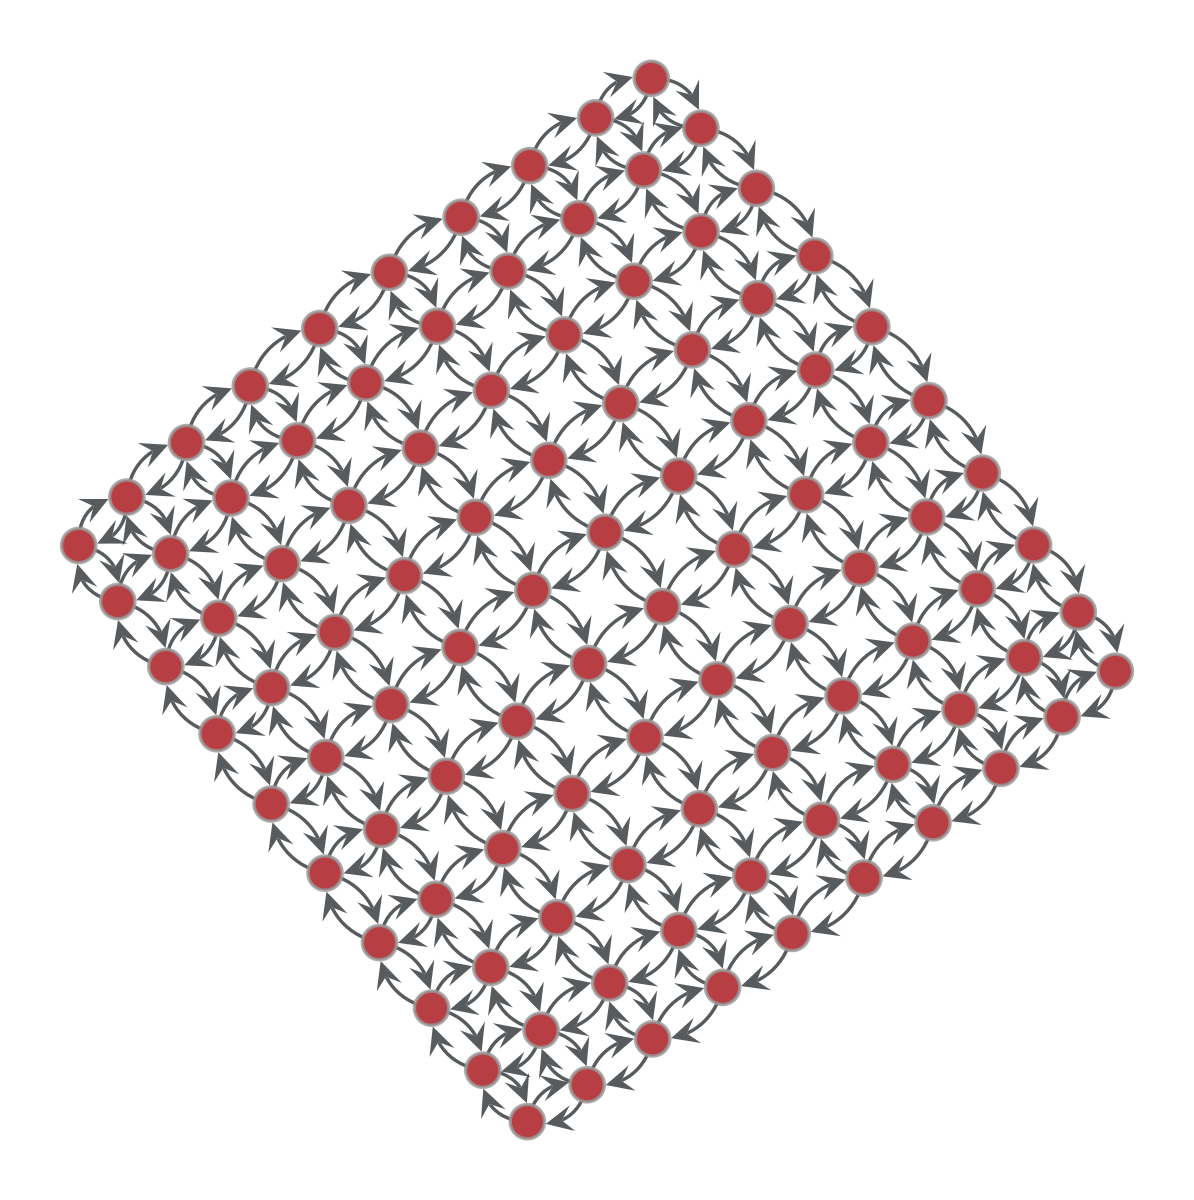

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x71dd11b37b00, at 0x71dd14cca6f0>

In [6]:
graph_draw(s[0].G)

In [7]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [8]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

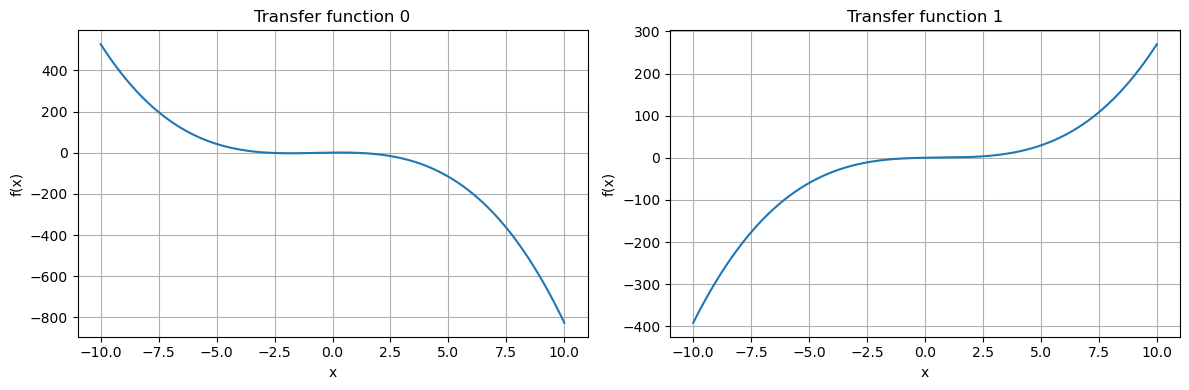

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

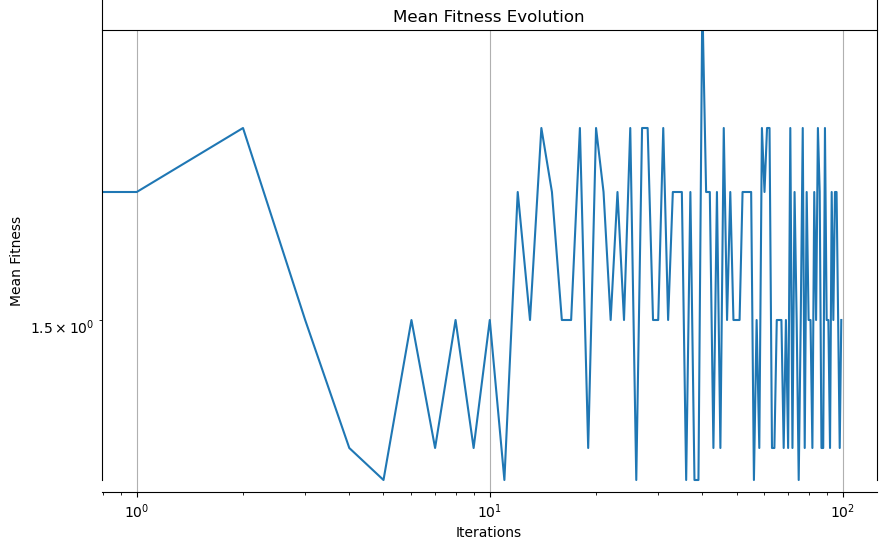

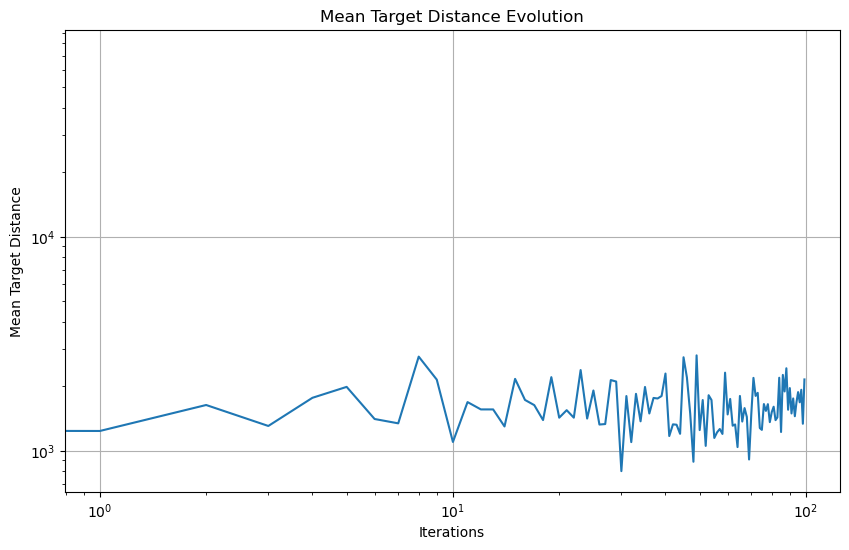

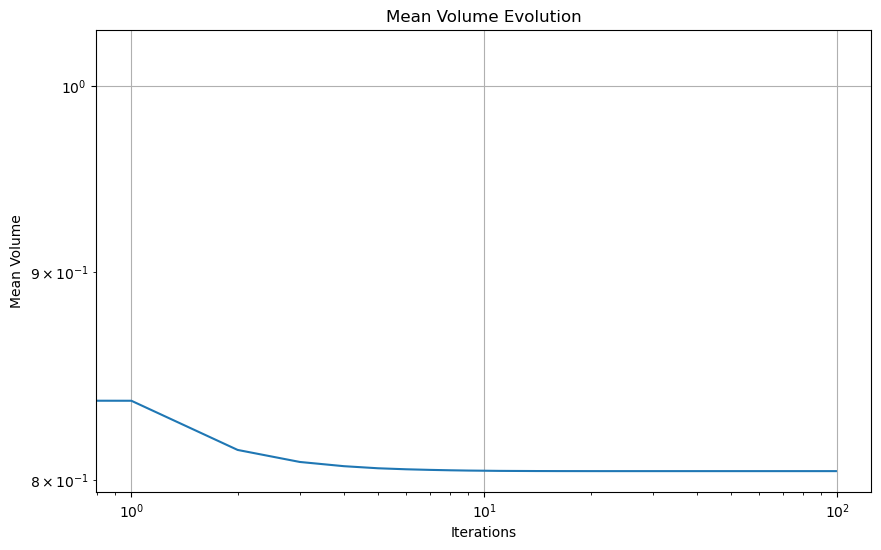

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(fmean)
plt.title('Mean Fitness Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Fitness')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()